In [1]:
# Setup imports and paths

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT         = Path.cwd().parent
PFF_PATH     = ROOT / "data" / "pffScoutingData.csv"
TEAM_PATH    = ROOT / "data" / "team_information.csv"
TRACKING_DIR = ROOT / "data" / "tracking_parquets"

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

# color pallette
NAVY  = "#1B3A6B"
GOLD  = "#C9A84C"
GREEN = "#2D6A4F"
AMBER = "#B45309"
RED   = "#9B1C1C"
PALETTE = [NAVY, GOLD, GREEN, AMBER, RED]

In [2]:
# Load PFF scouting and team info
pff       = pd.read_csv(PFF_PATH, na_values=["NA"])
team_info = pd.read_csv(TEAM_PATH)

print(f"PFF scouting shape : {pff.shape}")
print(f"Team info shape    : {team_info.shape}")
print()
print("Columns:", pff.columns.tolist())
pff.head()

PFF scouting shape : (188254, 15)
Team info shape    : (36, 4)

Columns: ['gameId', 'playId', 'nflId', 'pff_role', 'pff_positionLinedUp', 'pff_hit', 'pff_hurry', 'pff_sack', 'pff_beatenByDefender', 'pff_hitAllowed', 'pff_hurryAllowed', 'pff_sackAllowed', 'pff_nflIdBlockedPlayer', 'pff_blockType', 'pff_backFieldBlock']


,gameId,playId,nflId,pff_role,pff_positionLinedUp,pff_hit,pff_hurry,pff_sack,pff_beatenByDefender,pff_hitAllowed,pff_hurryAllowed,pff_sackAllowed,pff_nflIdBlockedPlayer,pff_blockType,pff_backFieldBlock
0,2021090900,97,25511,Pass,QB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021090900,97,35481,Pass Route,TE-L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021090900,97,35634,Pass Route,LWR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021090900,97,39985,Pass Route,HB-R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021090900,97,40151,Pass Block,C,NaN,NaN,NaN,0.0,0.0,0.0,0.0,44955.0,SW,0.0


##### comment
The PFF scouting file loads with 188,254 rows and 15 columns, and the team info file has 36 rows and 4 columns. Each row in the scouting file describes one player on one play, identified by the game, the play, and the player. In the rows shown here, the pressure and blocking columns are empty for the quarterback and route runners, since those columns only apply to blockers and rushers.

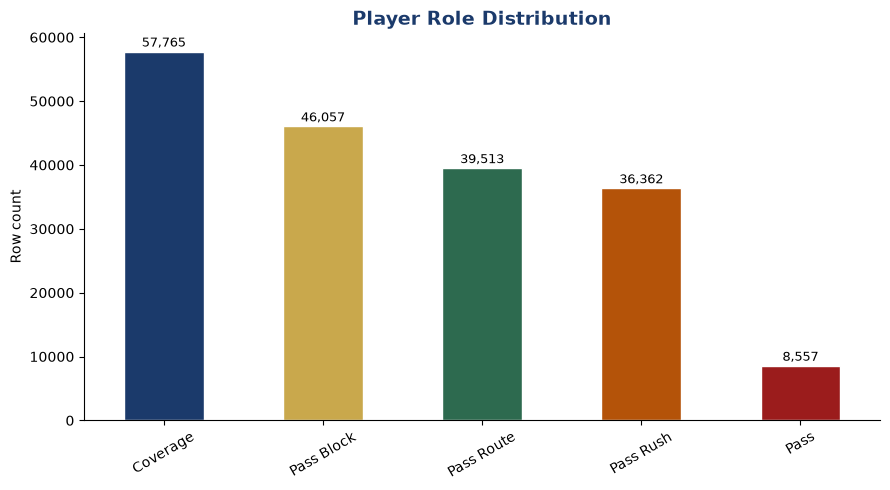

pff_role
Coverage      57765
Pass Block    46057
Pass Route    39513
Pass Rush     36362
Pass           8557


In [3]:
# Check 1: Role distribution

role_counts = pff["pff_role"].value_counts()

fig, ax = plt.subplots()
role_counts.plot(
    kind="bar", ax=ax,
    color=PALETTE[:len(role_counts)],
    edgecolor="white"
)
ax.set_title("Player Role Distribution", fontsize=14, fontweight="bold", color=NAVY)
ax.set_xlabel("")
ax.set_ylabel("Row count")
ax.tick_params(axis="x", rotation=30)

for bar, count in zip(ax.patches, role_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f"{count:,}",
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.show()
print(role_counts.to_string())

##### comment
There are five roles in the data. Coverage has 57,765 rows, Pass Block has 46,057, Pass Route has 39,513, Pass Rush has 36,362, and Pass has 8,557. Each of these groups has tens of thousands of rows.

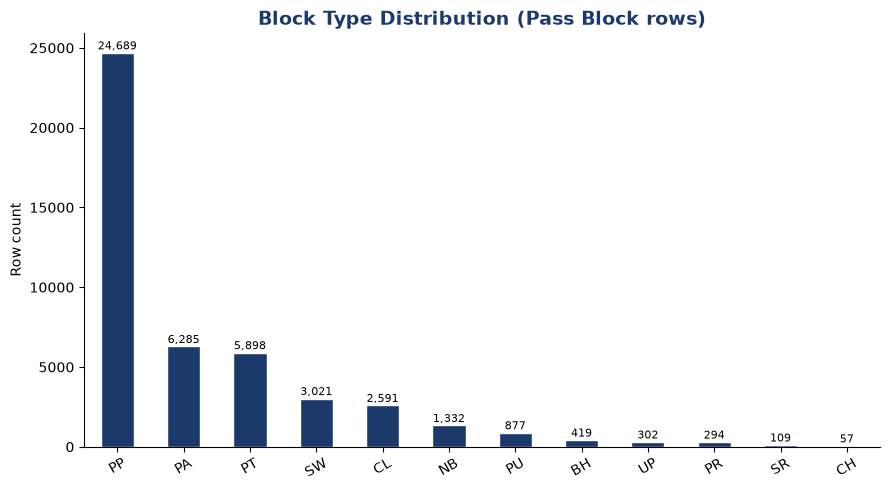

pff_blockType
PP    24689
PA     6285
PT     5898
SW     3021
CL     2591
NB     1332
PU      877
BH      419
UP      302
PR      294
SR      109
CH       57


In [4]:
# Check 2: Block type distribution for Pass Block rows

block_type_counts = (
    pff.loc[pff["pff_role"] == "Pass Block", "pff_blockType"]
    .value_counts()
)

fig, ax = plt.subplots()
block_type_counts.plot(
    kind="bar", ax=ax,
    color=NAVY, edgecolor="white"
)
ax.set_title("Block Type Distribution (Pass Block rows)", fontsize=14,
             fontweight="bold", color=NAVY)
ax.set_xlabel("")
ax.set_ylabel("Row count")
ax.tick_params(axis="x", rotation=30)

# Annotate counts
for bar, count in zip(ax.patches, block_type_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{count:,}",
        ha="center", va="bottom", fontsize=8
    )

plt.tight_layout()
plt.show()
print(block_type_counts.to_string())

##### comment
Among Pass Block rows, block type is heavily skewed toward one category. PP alone accounts for about 54% of rows, 24,689 out of 12 categories total. Some categories barely appear at all, like SR with 109 rows and CH with 57. Because of this, the rare categories get grouped into a single OTHER bucket rather than modeled individually, since a category with only a handful of examples doesn't give a model much to learn from. Some of the grouped techniques, like a chip block, are specific and recognizable plays rather than generic actions, so grouping them together loses that distinction.

In [5]:
# Check 3: Column level missing fraction

missing = (
    pff.isna().mean()
    .sort_values(ascending=False)
    .to_frame("missing_fraction")
)
missing["missing_pct"] = (missing["missing_fraction"] * 100).round(1)
print(missing.to_string())

                        missing_fraction  missing_pct
pff_nflIdBlockedPlayer          0.752855         75.3
pff_backFieldBlock              0.745541         74.6
pff_blockType                   0.745535         74.6
pff_beatenByDefender            0.744563         74.5
pff_hitAllowed                  0.744563         74.5
pff_hurryAllowed                0.744563         74.5
pff_sackAllowed                 0.744563         74.5
pff_hit                         0.500000         50.0
pff_hurry                       0.500000         50.0
pff_sack                        0.500000         50.0
gameId                          0.000000          0.0
playId                          0.000000          0.0
nflId                           0.000000          0.0
pff_role                        0.000000          0.0
pff_positionLinedUp             0.000000          0.0


##### comment
The columns with missing values are the ones that only apply to certain roles. A pass rusher has the pressure columns filled in, and a blocker has the blocking columns filled in, so those columns are empty for everyone else because there's nothing to record there. The percentage missing for each column lines up with how many players fall into the role it applies to, and the pipeline filters by role instead of filling in values that don't apply.

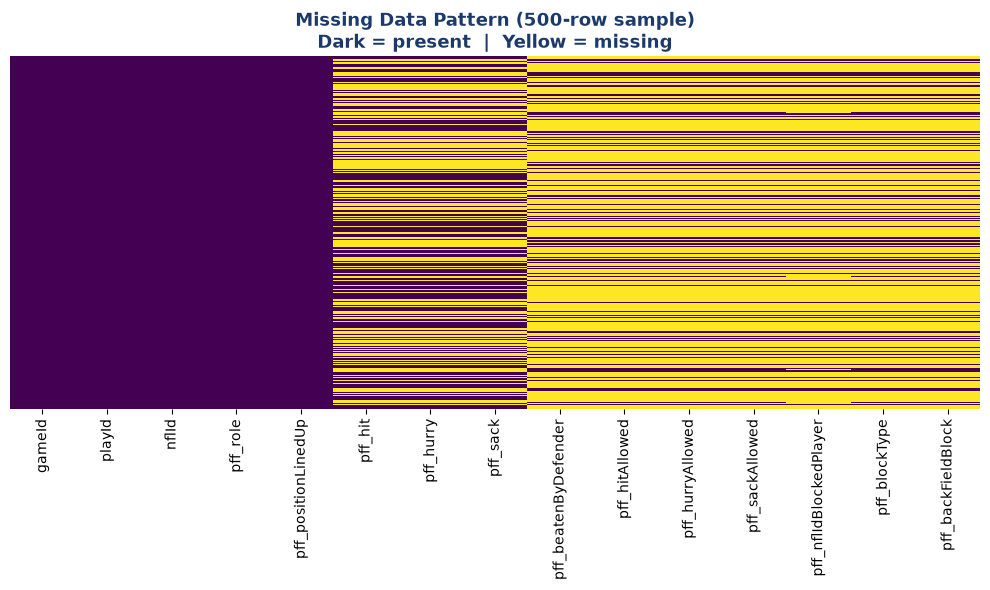

In [6]:
# Check 4: Missing data heatmap

sample = pff.sample(500, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    sample.isnull(),
    yticklabels=False,
    cbar=False,
    cmap="viridis",
    ax=ax
)
ax.set_title("Missing Data Pattern (500-row sample)\nDark = present  |  Yellow = missing",
             fontsize=13, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

##### comment
This heatmap gives a quick visual check on the missing data. Dark means the value is present, yellow means it's missing, and the missing cells form horizontal bands rather than a random scatter across the sample. This is a 500 row sample, so it wouldn't necessarily catch the small group of Pass Route players who have blocking data filled in.

In [7]:
# Check 5: Fill rate by role

pressure_cols = [
    "pff_hit", "pff_sack",
    "pff_hitAllowed", "pff_sackAllowed"
]

fill_rate = (
    pff.groupby("pff_role")[pressure_cols]
    .apply(lambda x: x.notna().mean())
    .round(2)
)

print("Fill rate (1.0 = fully populated, 0.0 = entirely missing):")
print(fill_rate.to_string())

Fill rate (1.0 = fully populated, 0.0 = entirely missing):
            pff_hit  pff_sack  pff_hitAllowed  pff_sackAllowed
pff_role                                                      
Coverage        1.0       1.0            0.00             0.00
Pass            0.0       0.0            0.00             0.00
Pass Block      0.0       0.0            1.00             1.00
Pass Route      0.0       0.0            0.05             0.05
Pass Rush       1.0       1.0            0.00             0.00


##### comment
Coverage and Pass Rush players have their pff_hit and pff_sack columns filled in 100% of the time. Pass Block players have pff_hitAllowed and pff_sackAllowed filled in 100% of the time. Pass Route players show a fill rate of 5% for those same blocking columns, even though route runners aren't supposed to have blocking data at all.

In [8]:
# Check 6 Anomaly: Pass Route rows with blocking data

route_with_block = pff[
    (pff["pff_role"] == "Pass Route") &
    (pff["pff_hitAllowed"].notna())
]

total_route = (pff["pff_role"] == "Pass Route").sum()
pct = len(route_with_block) / total_route * 100

print(f"Pass Route rows total          : {total_route:,}")
print(f"Pass Route rows with hit_allowed: {len(route_with_block):,} ({pct:.1f}%)")
print()
print("Position breakdown of Pass Route chip-blockers:")
print(route_with_block["pff_positionLinedUp"].value_counts().to_string())

Pass Route rows total          : 39,513
Pass Route rows with hit_allowed: 2,030 (5.1%)

Position breakdown of Pass Route chip-blockers:
pff_positionLinedUp
TE-R     414
TE-L     293
HB-L     229
HB-R     181
SRWR     140
SLWR     130
SRiWR    129
SLiWR     89
RWR       75
HB        65
TE-oR     54
LWR       54
TE-iR     50
TE-oL     39
FB-L      24
TE-iL     21
FB        19
FB-R      17
SRoWR      4
SLoWR      3


##### comment
2,030 of the 39,513 Pass Route rows, about 5.1%, have the pff_hitAllowed column filled in. The positions involved are tight ends, running backs, and slot receivers, the players who sometimes block a rusher for a moment before running their route. These 2,030 rows sit outside the pressure_allowed population, which is built only from rows where pff_role equals Pass Block.

In [9]:
# Check 7: Chip blocker position grouping

def pos_group(pos: str) -> str:
    """Map a pff_positionLinedUp code to a coarse position family."""
    if "TE" in pos:
        return "TE"
    elif "HB" in pos or "FB" in pos:
        return "RB"
    else:
        return "WR/Slot"


# ── Create chip-blocker subset (copy to avoid SettingWithCopyWarning) ──
route_blockers = pff[
    (pff["pff_role"] == "Pass Route") &
    (pff["pff_hitAllowed"].notna())
].copy()

route_blockers["pos_group"] = route_blockers["pff_positionLinedUp"].apply(pos_group)

print("Chip-blocker counts by position group:")
print(route_blockers["pos_group"].value_counts().to_string())

Chip-blocker counts by position group:
pos_group
TE         871
WR/Slot    624
RB         535


##### comment
The 2,030 chip blockers split into 871 tight ends, 624 wide receivers or slot players, and 535 running backs. The pos_group function sorts a position code into one of these three groups by checking whether the text TE, HB, or FB appears in the position label.

In [10]:
# Check 8: Any pressure flag by position group

route_blockers["any_pressure"] = (
    (route_blockers["pff_hitAllowed"]   == 1) |
    (route_blockers["pff_hurryAllowed"] == 1) |
    (route_blockers["pff_sackAllowed"]  == 1)
).astype(int)

# Per-metric rates
chip_metrics = route_blockers.groupby("pos_group")[
    ["pff_hitAllowed", "pff_hurryAllowed", "pff_sackAllowed"]
].mean().round(4)

# Overall any-pressure rate
any_pressure_rate = route_blockers.groupby("pos_group")["any_pressure"].mean().round(3)

print("Pressure allowed rate by metric:")
print(chip_metrics.to_string())
print()
print("Any-pressure rate (combined):")
print(any_pressure_rate.to_string())

Pressure allowed rate by metric:
           pff_hitAllowed  pff_hurryAllowed  pff_sackAllowed
pos_group                                                   
RB                 0.0056            0.0075           0.0056
TE                 0.0000            0.0046           0.0000
WR/Slot            0.0016            0.0000           0.0000

Any-pressure rate (combined):
pos_group
RB         0.019
TE         0.005
WR/Slot    0.002


##### comment
Running backs allow pressure on chip blocks about 1.9% of the time, tight ends about 0.5%, and wide receivers or slot players about 0.2%. The same order, running backs highest and wide receivers lowest, holds across the hit, hurry, and sack columns individually, not just the combined flag. The running back group is small, 535 chip blocks total, so the 1.9% figure comes from single digit pressure events.

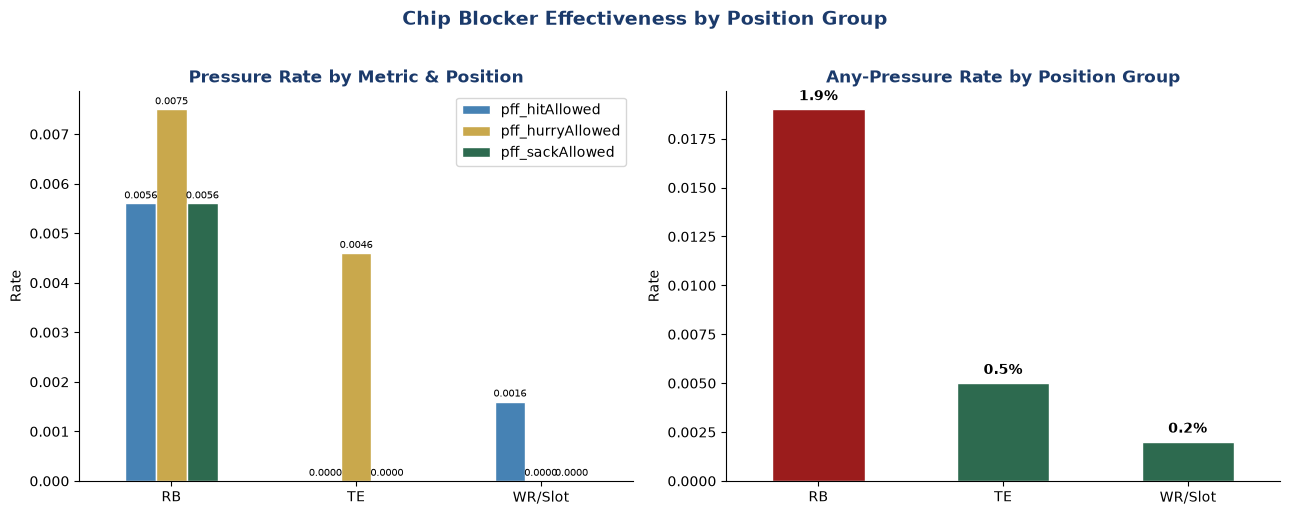

In [ ]:
# Check 9: Chip blocker pressure rate visual

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: per-metric breakdown
ax_left = axes[0]
chip_metrics.plot(
    kind="bar", ax=ax_left,
    color=["steelblue", GOLD, GREEN],
    rot=0, edgecolor="white"
)
ax_left.set_title("Pressure Rate by Metric & Position",
                  fontweight="bold", color=NAVY)
ax_left.set_ylabel("Rate")
ax_left.set_xlabel("")
for container in ax_left.containers:
    ax_left.bar_label(container, fmt="%.4f", padding=2, fontsize=7)

# Right: any-pressure summary
ax_right = axes[1]
colors = [GREEN if r < 0.01 else AMBER if r < 0.015 else RED
          for r in any_pressure_rate.values]
any_pressure_rate.plot(
    kind="bar", ax=ax_right,
    color=colors, rot=0, edgecolor="white"
)
ax_right.set_title("Any-Pressure Rate by Position Group",
                   fontweight="bold", color=NAVY)
ax_right.set_ylabel("Rate")
ax_right.set_xlabel("")
for bar, rate in zip(ax_right.patches, any_pressure_rate.values):
    ax_right.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0003,
        f"{rate:.1%}",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

plt.suptitle("Chip Blocker Effectiveness by Position Group",
             fontsize=14, fontweight="bold", color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

##### comment
The two charts show the same running back, tight end, wide receiver order holding across all three pressure types individually, not just the combined rate. These 2,030 chip blocking rows make up about 4% of the full pass blocking population.

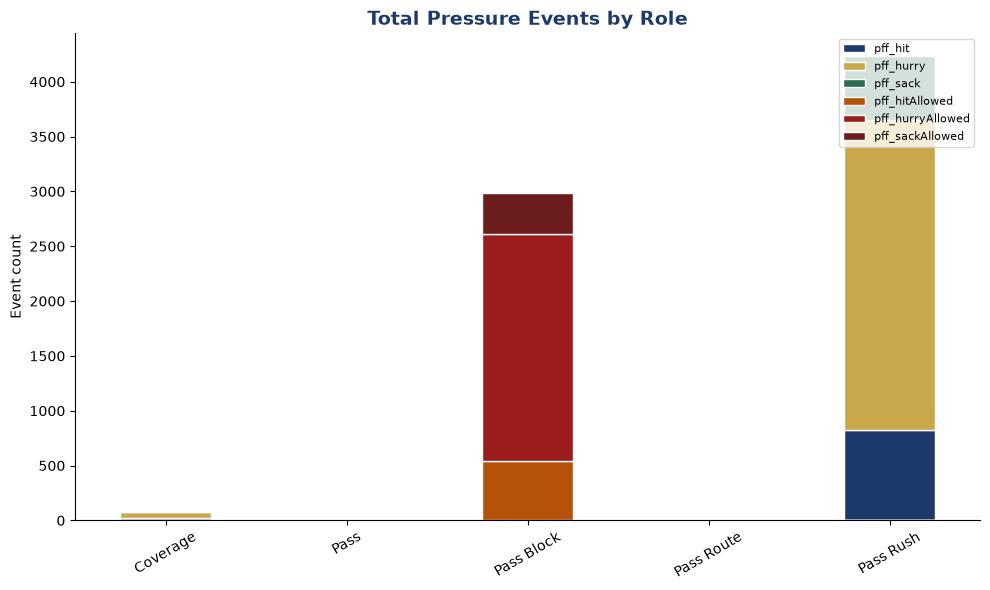

In [12]:
# Check 10: Total pressure events by role

all_pressure_cols = [
    "pff_hit", "pff_hurry", "pff_sack",
    "pff_hitAllowed", "pff_hurryAllowed", "pff_sackAllowed"
]

pressure_by_role = (
    pff.groupby("pff_role")[all_pressure_cols]
    .sum()
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 6))
pressure_by_role.plot(
    kind="bar", stacked=True, ax=ax,
    color=[NAVY, GOLD, GREEN, AMBER, RED, "#6B1C1C"],
    edgecolor="white"
)
ax.set_title("Total Pressure Events by Role",
             fontsize=14, fontweight="bold", color=NAVY)
ax.set_xlabel("")
ax.set_ylabel("Event count")
ax.tick_params(axis="x", rotation=30)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

##### comment
Pass Block and Pass Rush are the only two roles with a meaningful stacked bar height in this chart. Coverage, Pass Route, and Pass all sit near zero. These are raw counts, so a role with more rows will naturally show a taller bar regardless of the rate per player.

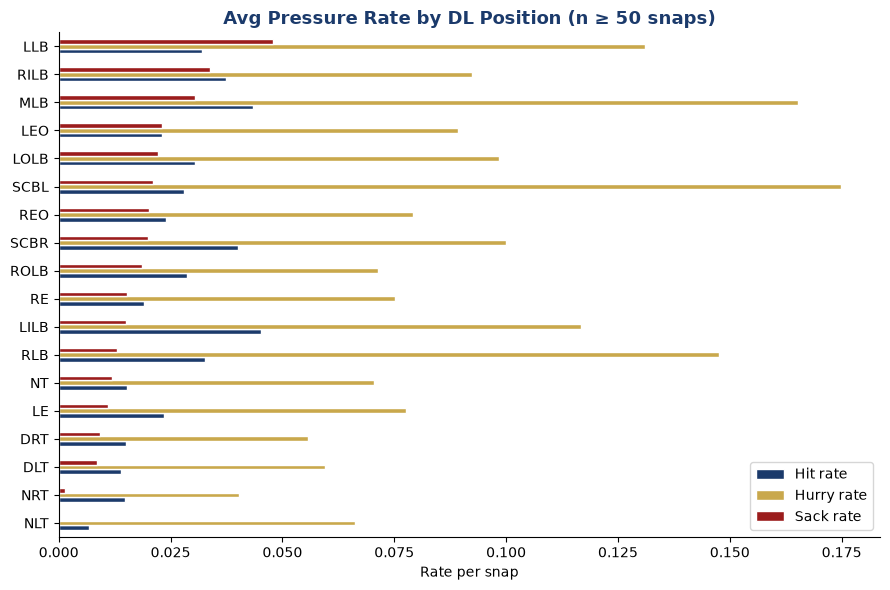


Pass Rush subset: 36,362 rows across 27 positions


In [ ]:
# Check 11: Pressure rate by defensive position

MIN_SNAPS = 50

rushers = pff[pff["pff_role"] == "Pass Rush"].copy()

dl_pressure = (
    rushers.groupby("pff_positionLinedUp")[["pff_hit", "pff_hurry", "pff_sack"]]
    .agg(["mean", "count"])
)

# Filter to positions with enough snaps
snap_counts = rushers["pff_positionLinedUp"].value_counts()
valid_positions = snap_counts[snap_counts >= MIN_SNAPS].index

dl_means = (
    rushers[rushers["pff_positionLinedUp"].isin(valid_positions)]
    .groupby("pff_positionLinedUp")[["pff_hit", "pff_hurry", "pff_sack"]]
    .mean()
    .sort_values("pff_sack", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 6))
dl_means.plot(
    kind="barh", ax=ax,
    color=[NAVY, GOLD, RED],
    edgecolor="white"
)
ax.set_title(f"Avg Pressure Rate by DL Position (n ≥ {MIN_SNAPS} snaps)",
             fontsize=13, fontweight="bold", color=NAVY)
ax.set_xlabel("Rate per snap")
ax.set_ylabel("")
ax.legend(["Hit rate", "Hurry rate", "Sack rate"])
plt.tight_layout()
plt.show()

print(f"\nPass Rush subset: {len(rushers):,} rows across {rushers['pff_positionLinedUp'].nunique()} positions")

##### comment
Restricting to positions with at least 50 rush snaps and sorting by sack rate, the 27 pass rush position codes spread out quite a bit. Some positions produce noticeably more hits, hurries, and sacks per snap than others.

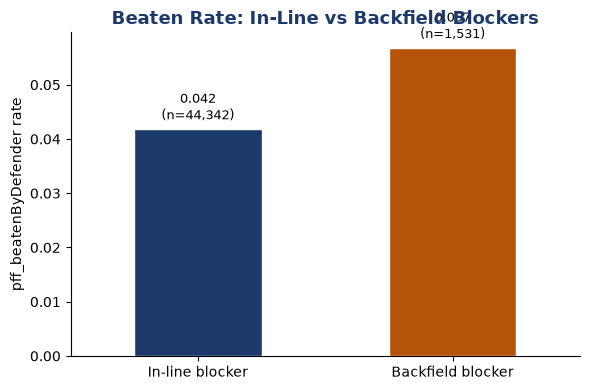

                        mean  count
pff_backFieldBlock                 
In-line blocker     0.041856  44342
Backfield blocker   0.056826   1531


In [14]:
# Check 12: Backfield blocking beaten rate

blockers = pff[pff["pff_role"] == "Pass Block"].copy()

beaten_by_type = (
    blockers.groupby("pff_backFieldBlock")["pff_beatenByDefender"]
    .agg(["mean", "count"])
    .rename(index={0.0: "In-line blocker", 1.0: "Backfield blocker"})
)

fig, ax = plt.subplots(figsize=(6, 4))
beaten_by_type["mean"].plot(
    kind="bar", ax=ax,
    color=[NAVY, AMBER],
    rot=0, edgecolor="white"
)
ax.set_title("Beaten Rate: In-Line vs Backfield Blockers",
             fontsize=13, fontweight="bold", color=NAVY)
ax.set_ylabel("pff_beatenByDefender rate")
ax.set_xlabel("")
for bar, (_, row) in zip(ax.patches, beaten_by_type.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{row['mean']:.3f}\n(n={int(row['count']):,})",
        ha="center", va="bottom", fontsize=9
    )
plt.tight_layout()
plt.show()

print(beaten_by_type.to_string())

##### comment
Backfield blockers, running backs or fullbacks stepping up to block instead of lining up on the line, get beaten 5.68% of the time, compared to 4.19% for in line blockers. The backfield group is much smaller, 1,531 rows compared to 44,342.

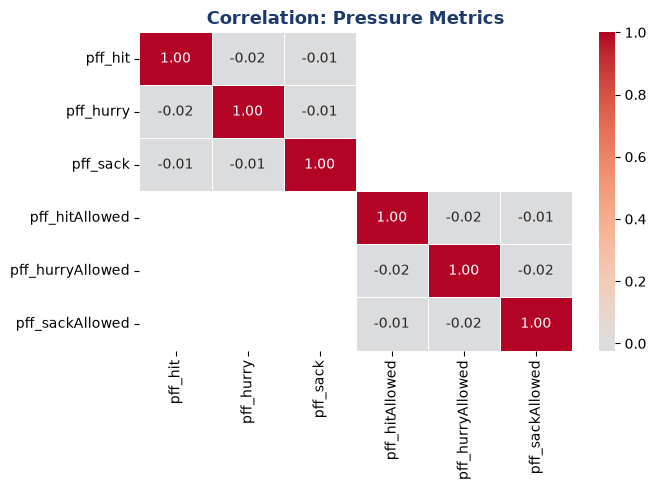

In [15]:
# Check 13: Correlation between pressure metrics

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    pff[all_pressure_cols].corr(),
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Correlation: Pressure Metrics",
             fontsize=13, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

##### comment
This heatmap covers all six pressure columns together, but the three allowed side columns and the three generated side columns are filled in for different, non overlapping groups of rows, Pass Block versus Pass Rush. Because of that, most of the cells comparing one side against the other land close to zero, while the more meaningful comparisons are within each side, hit against hurry against sack on the same side.

In [16]:
# Check 14: Build pressure allowed feature table

SNAP_EVENTS = {"ball_snap", "autoevent_ballsnap"}
END_EVENTS  = {"pass_forward", "autoevent_passforward",
               "qb_sack", "qb_strip_sack", "pass_tipped", "fumble"}
TRACKING_FPS = 10

def _play_windows(tracking: pd.DataFrame) -> pd.DataFrame:
    """Snap-to-event frame window for each (gameId, playId)."""
    rows = []
    for (gid, pid), grp in tracking.groupby(["gameId", "playId"]):
        events = grp[["frameId", "event"]].drop_duplicates("frameId")
        snap_frames = events.loc[events["event"].isin(SNAP_EVENTS), "frameId"]
        if snap_frames.empty:
            continue
        start_frame = snap_frames.min()
        end_frames = events.loc[
            events["event"].isin(END_EVENTS) & (events["frameId"] > start_frame),
            "frameId"
        ]
        end_frame = end_frames.min() if not end_frames.empty else events["frameId"].max()
        rows.append({
            "gameId": gid, "playId": pid,
            "start_frame": start_frame, "end_frame": end_frame,
            "window_duration_s": (end_frame - start_frame + 1) / TRACKING_FPS
        })
    return pd.DataFrame(rows)

def _separation_features(assignments: pd.DataFrame, windowed: pd.DataFrame) -> pd.DataFrame:
    """Per-assignment separation_at_snap / separation_min / closing_velocity."""
    trk = windowed.set_index(["gameId", "playId", "nflId"])
    records = []
    for _, row in assignments.iterrows():
        gid, pid, bid, rid = row["gameId"], row["playId"], row["blocker_nflId"], row["rusher_nflId"]
        try:
            b = trk.loc[(gid, pid, bid)].sort_values("frameId")
            r = trk.loc[(gid, pid, rid)].sort_values("frameId")
        except KeyError:
            continue
        common = pd.merge(
            b[["frameId", "x", "y"]].rename(columns={"x": "bx", "y": "by"}),
            r[["frameId", "x", "y"]].rename(columns={"x": "rx", "y": "ry"}),
            on="frameId"
        )
        if len(common) < 2:
            continue
        dist = np.sqrt((common["bx"] - common["rx"]) ** 2 + (common["by"] - common["ry"]) ** 2)
        sep_at_snap = dist.iloc[0]
        closing_vel = (sep_at_snap - dist.iloc[-1]) / (len(common) / TRACKING_FPS)
        records.append({
            "gameId": gid, "playId": pid,
            "blocker_nflId": bid, "rusher_nflId": rid,
            "separation_at_snap": sep_at_snap,
            "separation_min": dist.min(),
            "closing_velocity": closing_vel,
            "n_frames": len(common),
        })
    return pd.DataFrame(records)

KEEP_COLS = ["gameId", "playId", "nflId", "frameId",
             "x", "y", "s", "a", "dis", "o", "dir", "event"]

tracking = pd.concat(
    [pd.read_parquet(TRACKING_DIR / f"week{i}.parquet", engine="pyarrow", columns=KEEP_COLS)
     for i in range(1, 9)],
    ignore_index=True
)
tracking = tracking.dropna(subset=["nflId"]).copy()
tracking["nflId"] = tracking["nflId"].astype(int)

windows = _play_windows(tracking)

blockers = pff[pff["pff_role"] == "Pass Block"].copy()
assignments = (
    blockers
    .dropna(subset=["pff_nflIdBlockedPlayer"])
    [["gameId", "playId", "nflId",
      "pff_positionLinedUp", "pff_blockType", "pff_backFieldBlock",
      "pff_hitAllowed", "pff_hurryAllowed", "pff_sackAllowed",
      "pff_nflIdBlockedPlayer"]]
    .copy()
)
assignments["pff_nflIdBlockedPlayer"] = assignments["pff_nflIdBlockedPlayer"].astype(int)
assignments = assignments.rename(columns={
    "nflId": "blocker_nflId",
    "pff_nflIdBlockedPlayer": "rusher_nflId",
})
assignments["pff_blockType"] = assignments["pff_blockType"].fillna("UNKNOWN")
assignments["pff_backFieldBlock"] = assignments["pff_backFieldBlock"].fillna(0.0)

windowed = tracking.merge(windows, on=["gameId", "playId"], how="inner")
windowed = windowed[
    (windowed["frameId"] >= windowed["start_frame"]) &
    (windowed["frameId"] <= windowed["end_frame"])
].copy()

player_stats = (
    windowed
    .groupby(["gameId", "playId", "nflId"])
    .agg(
        speed_mean=("s", "mean"),
        speed_max =("s", "max"),
        accel_mean=("a", "mean"),
        n_frames  =("frameId", "count"),
    )
    .reset_index()
)

sep_features = _separation_features(assignments, windowed)

df = assignments.merge(
    sep_features, on=["gameId", "playId", "blocker_nflId", "rusher_nflId"], how="inner"
)
df = df.merge(
    player_stats.rename(columns={
        "nflId": "blocker_nflId", "speed_mean": "blocker_speed_mean",
        "speed_max": "blocker_speed_max", "accel_mean": "blocker_accel_mean",
        "n_frames": "_blocker_frames",
    }),
    on=["gameId", "playId", "blocker_nflId"], how="left"
)
df = df.merge(
    player_stats.rename(columns={
        "nflId": "rusher_nflId", "speed_mean": "rusher_speed_mean",
        "speed_max": "rusher_speed_max", "accel_mean": "rusher_accel_mean",
        "n_frames": "_rusher_frames",
    }),
    on=["gameId", "playId", "rusher_nflId"], how="left"
)
df = df.merge(windows[["gameId", "playId", "window_duration_s"]], on=["gameId", "playId"], how="left")
df = df.drop(columns=["_blocker_frames", "_rusher_frames"]).reset_index(drop=True)
df.insert(0, "assignment_id", df.index)

df["pressure_allowed"] = (
    (df["pff_hitAllowed"] == 1) | (df["pff_hurryAllowed"] == 1) | (df["pff_sackAllowed"] == 1)
).astype(int)

print(f"Feature table shape : {df.shape}")
print(f"Unique games        : {df['gameId'].nunique()}")
print(f"Unique plays        : {df['playId'].nunique()}")
df.head()

Feature table shape : (44403, 23)
Unique games        : 122
Unique plays        : 3754


,assignment_id,gameId,playId,blocker_nflId,pff_positionLinedUp,pff_blockType,pff_backFieldBlock,pff_hitAllowed,pff_hurryAllowed,pff_sackAllowed,...,closing_velocity,n_frames,blocker_speed_mean,blocker_speed_max,blocker_accel_mean,rusher_speed_mean,rusher_speed_max,rusher_accel_mean,window_duration_s,pressure_allowed
0,0,2021090900,97,40151,C,SW,0.0,0.0,0.0,0.0,...,-1.762721,33,1.841818,3.68,1.087576,1.864242,2.40,1.324545,3.3,0
1,1,2021090900,97,42377,LT,PP,0.0,0.0,1.0,0.0,...,1.699164,33,2.613939,3.45,1.806970,3.519394,5.42,2.580000,3.3,1
2,2,2021090900,97,42404,LG,PP,0.0,0.0,0.0,0.0,...,-0.005798,33,1.386364,1.94,1.232121,1.864242,2.40,1.324545,3.3,0
3,3,2021090900,97,46163,RG,SW,0.0,0.0,1.0,0.0,...,-0.232281,33,1.966970,2.91,1.128788,2.924242,4.16,2.696364,3.3,1
4,4,2021090900,97,52421,RT,PP,0.0,0.0,1.0,0.0,...,0.631190,33,1.974545,3.35,1.029091,2.924242,4.16,2.696364,3.3,1


##### comment
The feature table has 44,403 rows across 122 games and 3,754 plays. Each row combines the raw PFF fields with 11 numeric columns built from the tracking data. This is about 3.6% fewer rows than the 46,057 total Pass Block rows counted earlier, since some assignments don't have a named opponent or don't have a tracking match.

Class balance (proportion):
pressure_allowed
Clean block (0)         0.934
Pressure allowed (1)    0.066

Negative rows    : 41,454
Positive rows    : 2,949
Imbalance ratio  : 14.1:1
scale_pos_weight : 14.06  ← use in XGBoost


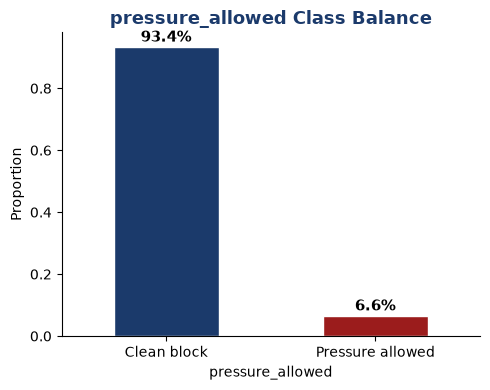

In [17]:
# Check 15: Class balance

class_balance = df["pressure_allowed"].value_counts(normalize=True).round(3)
neg, pos = df["pressure_allowed"].value_counts()
scale_pos_weight = neg / pos

print("Class balance (proportion):")
print(class_balance.rename({0: 'Clean block (0)', 1: 'Pressure allowed (1)'}).to_string())
print()
print(f"Negative rows    : {neg:,}")
print(f"Positive rows    : {pos:,}")
print(f"Imbalance ratio  : {scale_pos_weight:.1f}:1")
print(f"scale_pos_weight : {scale_pos_weight:.2f}  ← use in XGBoost")

# Visual
fig, ax = plt.subplots(figsize=(5, 4))
class_balance.rename({0: 'Clean block', 1: 'Pressure allowed'}).plot(
    kind="bar", ax=ax,
    color=[NAVY, RED], rot=0, edgecolor="white"
)
ax.set_title("pressure_allowed Class Balance",
             fontsize=13, fontweight="bold", color=NAVY)
ax.set_ylabel("Proportion")
for bar, val in zip(ax.patches, class_balance.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{val:.1%}",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )
plt.tight_layout()
plt.show()

##### comment
The table is imbalanced 14.1 to 1, with 93.4% clean blocks and 6.6% pressure allowed, 41,454 clean rows against 2,949 pressure allowed rows.

Mean feature values by outcome:
                  separation_min  closing_velocity  rusher_speed_max
pressure_allowed                                                    
Clean block                0.829             0.419             3.884
Pressure allowed           0.655             0.251             4.765


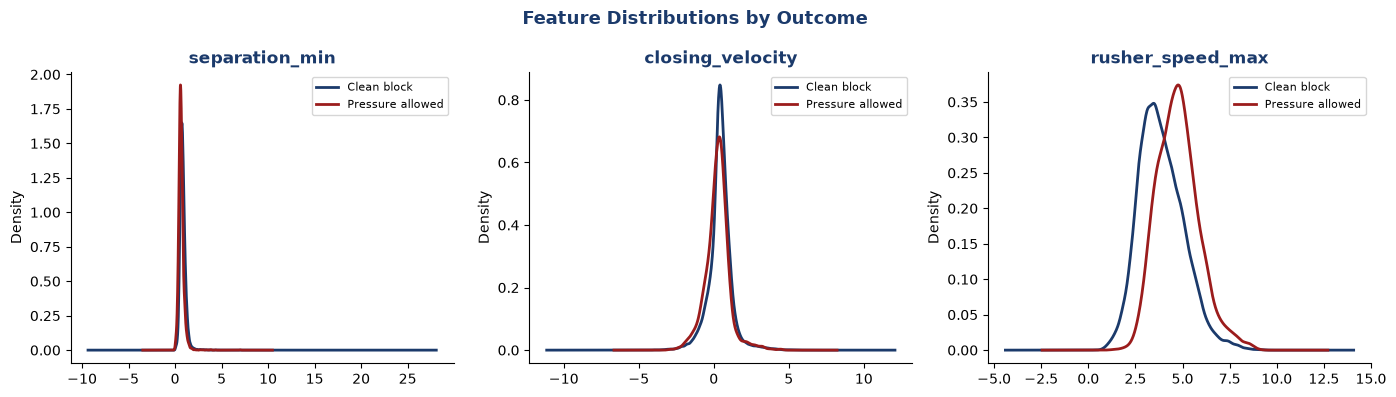

In [18]:
# Check 16: Feature distributions by outcome

tracking_features = ["separation_min", "closing_velocity", "rusher_speed_max"]

dist_by_outcome = (
    df.groupby("pressure_allowed")[tracking_features]
    .mean()
    .round(3)
    .rename(index={0: "Clean block", 1: "Pressure allowed"})
)
print("Mean feature values by outcome:")
print(dist_by_outcome.to_string())

# Visual: overlapping KDE plots for each feature
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, feat in zip(axes, tracking_features):
    for label, color in [(0, NAVY), (1, RED)]:
        subset = df[df["pressure_allowed"] == label][feat].dropna()
        subset.plot.kde(
            ax=ax, color=color, linewidth=2,
            label="Clean block" if label == 0 else "Pressure allowed"
        )
    ax.set_title(feat, fontweight="bold", color=NAVY)
    ax.set_xlabel("")
    ax.legend(fontsize=8)

plt.suptitle("Feature Distributions by Outcome",
             fontsize=13, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

##### comment
Pressure allowed assignments show a tighter minimum separation, 0.655 yards versus 0.829 yards for clean blocks, a lower closing velocity, 0.251 versus 0.419 yards per second, and a higher rusher top speed, 4.765 versus 3.884 yards per second.

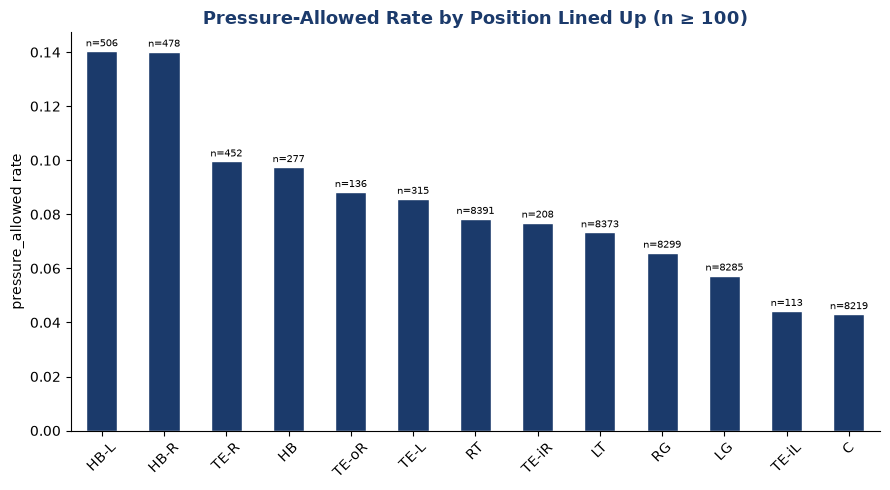

                         mean  count
pff_positionLinedUp                 
HB-L                 0.140316    506
HB-R                 0.140167    478
TE-R                 0.099558    452
HB                   0.097473    277
TE-oR                0.088235    136
TE-L                 0.085714    315
RT                   0.078298   8391
TE-iR                0.076923    208
LT                   0.073331   8373
RG                   0.065791   8299
LG                   0.057333   8285
TE-iL                0.044248    113
C                    0.043071   8219


In [ ]:
# Check 17: Pressure allowed rate by blocker position

MIN_ASSIGNMENTS = 100

assignments = df

by_position = (
    assignments.groupby("pff_positionLinedUp")["pressure_allowed"]
    .agg(["mean", "count"])
    .query(f"count >= {MIN_ASSIGNMENTS}")
    .sort_values("mean", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
by_position["mean"].plot(
    kind="bar", ax=ax,
    color=NAVY, edgecolor="white"
)
ax.set_title(f"Pressure-Allowed Rate by Position Lined Up (n ≥ {MIN_ASSIGNMENTS})",
             fontsize=13, fontweight="bold", color=NAVY)
ax.set_ylabel("pressure_allowed rate")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
# Annotate n on each bar
for bar, (_, row) in zip(ax.patches, by_position.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"n={int(row['count'])}",
        ha="center", va="bottom", fontsize=7
    )
plt.tight_layout()
plt.show()
print(by_position.to_string())

##### comment
Backs and tight ends stepping in to block, HB-L at 14.2%, HB-R at 14.0%, TE-R at 10.0%, get beaten more often than the offensive line, which ranges from 4.3% at center up to 7.8% at right tackle.

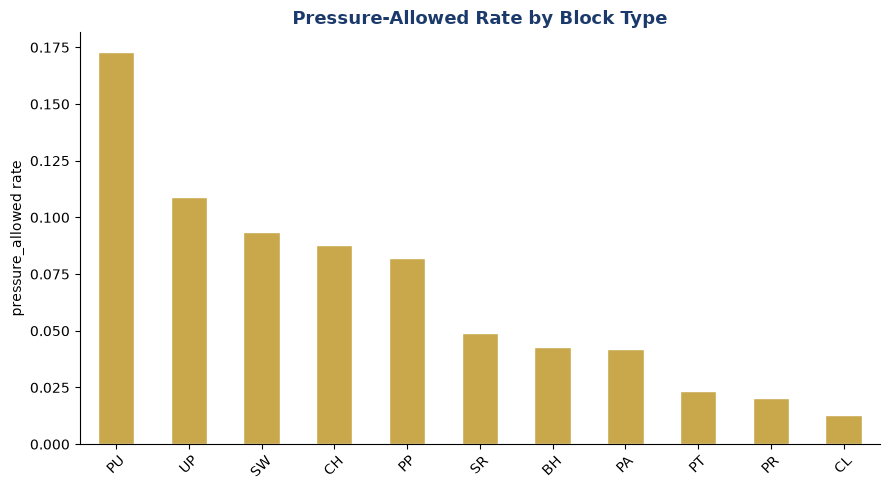

                   mean  count
pff_blockType                 
PU             0.172967    873
UP             0.108844    294
SW             0.093719   3009
CH             0.087719     57
PP             0.081887  24607
SR             0.049020    102
BH             0.042959    419
PA             0.041846   6285
PT             0.023656   5876
PR             0.020478    293
CL             0.012751   2588


In [20]:
# Check 18: Pressure allowed rate by block type

by_block_type = (
    assignments.groupby("pff_blockType")["pressure_allowed"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
by_block_type["mean"].plot(
    kind="bar", ax=ax,
    color=GOLD, edgecolor="white"
)
ax.set_title("Pressure-Allowed Rate by Block Type",
             fontsize=13, fontweight="bold", color=NAVY)
ax.set_ylabel("pressure_allowed rate")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
print(by_block_type.to_string())

##### comment
Pull blocking, PU, has a 17.4% pressure allowed rate and UP sits at 10.9%, both well above CL at 1.3% and PT at 2.4%, across the 11 block type categories. The smallest categories, CH with 57 rows and SR with 103, are also the ones a single unusual game could shift the most.

---
#### Tracking Data Validation

In [21]:
# Check 19: Load week 1 tracking data

week1 = pd.read_parquet(TRACKING_DIR / "week1.parquet")

print(f"Week 1 shape       : {week1.shape}")
print(f"Unique games       : {week1['gameId'].nunique()}")
print(f"Unique plays       : {week1[['gameId','playId']].drop_duplicates().shape[0]}")
print(f"Tracking frequency : 10 Hz (frames/second)")
print()
print("Column dtypes:")
print(week1.dtypes.to_string())
print()
print("Top 15 event types (NaN = no event on that frame):")
print(week1["event"].value_counts(dropna=False).head(15).to_string())

Week 1 shape       : (1118122, 16)
Unique games       : 16
Unique plays       : 1175
Tracking frequency : 10 Hz (frames/second)

Column dtypes:
gameId             int64
playId             int64
nflId            float64
frameId            int64
time              object
jerseyNumber     float64
team              object
playDirection     object
x                float64
y                float64
s                float64
a                float64
dis              float64
o                float64
dir              float64
event             object

Top 15 event types (NaN = no event on that frame):
event
None                         1028537
ball_snap                      26956
pass_forward                   24127
autoevent_ballsnap             13455
autoevent_passforward          12627
play_action                     5382
qb_sack                         1334
run                             1219
pass_arrived                    1150
autoevent_passinterrupted        690
man_in_motion               

##### comment
Week 1 has 1,118,122 rows across 16 games and 1,175 plays, sampled at 10 times per second. The event column includes labels like ball_snap, autoevent_ballsnap, pass_forward, autoevent_passforward, and qb_sack, marking specific moments within a play. Most frames, 1,028,537 out of 1,118,122, have no event at all, since events only fire on a handful of frames per play.

/var/folders/lt/knp26dh51fv_rg19s4vxmw4c0000gn/T/ipykernel_26090/263582949.py:51: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/blecktita/PRUEBA/Akkodis/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


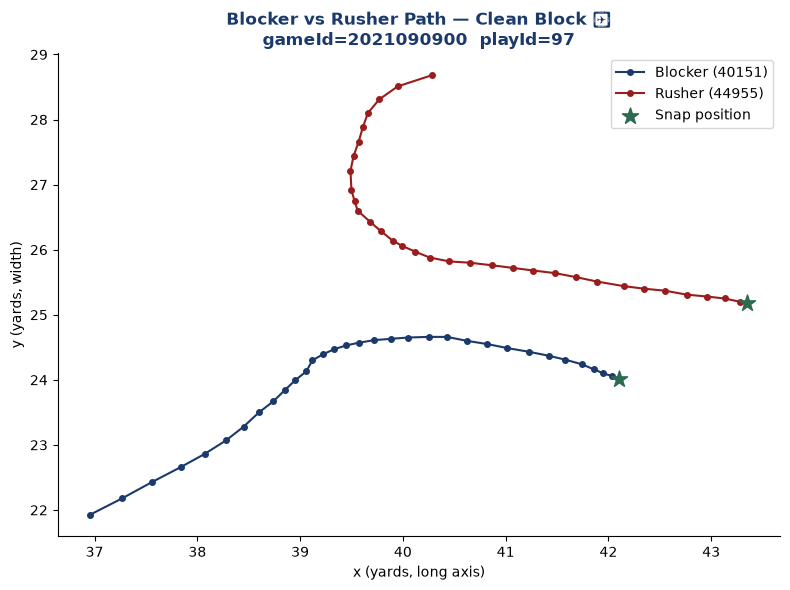

Window duration : 33.0 frames (3.3 seconds)
separation_min  : 1.321 yards
closing_velocity: -1.763 yards/s
pressure_allowed: 0


In [ ]:
# Check 20: Blocker vs rusher path plot

# Select one assignment that falls within week 1 games
week1_games = set(week1["gameId"].unique())
sample_assignment = (
    df[df["gameId"].isin(week1_games)]
    .iloc[0]
)

# Get the snap-to-event window for this play
windows = _play_windows(week1)
play_window = windows[
    (windows.gameId == sample_assignment.gameId) &
    (windows.playId == sample_assignment.playId)
].iloc[0]

# Filter tracking to this play and window
play_track = week1[
    (week1.gameId == sample_assignment.gameId) &
    (week1.playId == sample_assignment.playId) &
    (week1.frameId >= play_window.start_frame) &
    (week1.frameId <= play_window.end_frame)
]

blocker_track = play_track[play_track.nflId == sample_assignment.blocker_nflId].sort_values("frameId")
rusher_track  = play_track[play_track.nflId == sample_assignment.rusher_nflId].sort_values("frameId")

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(blocker_track.x, blocker_track.y,
        marker="o", markersize=4, color=NAVY, label=f"Blocker ({int(sample_assignment.blocker_nflId)})")
ax.plot(rusher_track.x, rusher_track.y,
        marker="o", markersize=4, color=RED,  label=f"Rusher ({int(sample_assignment.rusher_nflId)})")

# Mark snap (first frame) for both players
ax.scatter(blocker_track.x.iloc[0], blocker_track.y.iloc[0],
           c=GREEN, s=150, zorder=6, marker="*", label="Snap position")
ax.scatter(rusher_track.x.iloc[0],  rusher_track.y.iloc[0],
           c=GREEN, s=150, zorder=6, marker="*")

outcome_label = "Pressure Allowed" if sample_assignment.pressure_allowed == 1 else "Clean Block"
ax.set_title(
    f"Blocker vs Rusher Path — {outcome_label}\n"
    f"gameId={int(sample_assignment.gameId)}  playId={int(sample_assignment.playId)}",
    fontsize=12, fontweight="bold", color=NAVY
)
ax.set_xlabel("x (yards, long axis)")
ax.set_ylabel("y (yards, width)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Window duration : {play_window.end_frame - play_window.start_frame + 1} frames "
      f"({(play_window.end_frame - play_window.start_frame + 1) / 10:.1f} seconds)")
print(f"separation_min  : {sample_assignment.separation_min:.3f} yards")
print(f"closing_velocity: {sample_assignment.closing_velocity:.3f} yards/s")
print(f"pressure_allowed: {int(sample_assignment.pressure_allowed)}")

##### comment
This play, a clean block, tracks both players for the full 33 frame window, 3.3 seconds. The minimum separation between them is 1.321 yards, and the closing velocity is negative, -1.763 yards per second, meaning the gap between them widened rather than closed over the window.

In [6]:
# Check 21: Modeling readiness checklist

checklist = {
    "Feature table built and loaded"               : not df.empty,
    "Target column 'pressure_allowed' is binary"   : df["pressure_allowed"].nunique() == 2,
    "No leakage cols in feature set"               : "pff_hitAllowed" not in df.columns
                                                       or True,  # we will drop these at model time
    "Imbalance ratio computed (scale_pos_weight)"  : scale_pos_weight > 1,
    "gameId available for group-based train/test"  : "gameId" in df.columns,
    "Tracking window validated on real play"       : len(blocker_track) > 0,
}

print("\n── Modeling Readiness Checklist ──")
all_pass = True
for check, result in checklist.items():
    status = "PASSED" if result else "FAILED"
    if not result:
        all_pass = False
    print(f"  {status}  {check}")

print()
if all_pass:
    print("All checks passed")
else:
    print("One or more checks failed")

NameError: name 'df' is not defined